In [1]:
from google.colab import files
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
uploaded = files.upload()

Saving merged_data.csv to merged_data.csv


In [3]:
#used built-in Gemini
merged = pd.read_csv("merged_data.csv")

habitats = [
    "Forest_Present",
    "Marsh_Present",
    "Dune_Present",
    "Oyster_Reef_Present",
    "Underwater_Grass_Present"
]
hazard_mapping = {
    'Very Low': 0,
    'Low': 1,
    'Moderate': 2,
    'High': 3,
    'Very High': 4
}
hazard_order = ["Very Low", "Low", "Moderate", "High", "Very High"]
hazard_cols = [
    'Geomorphology_Hazard', 'Elevation_Hazard',
    'Sea_Level_Rise_Hazard', 'Wave_Hazard',
    'storm_surge_hazard', 'Erosion_Rate_Hazard'
]


for h in habitats:
    if h in merged.columns:

        merged.loc[:, h] = merged[h].fillna(0).astype(int)


if 'Hazard_Reduction_by_Habitats' in merged.columns:
    merged.loc[:, 'Hazard_Reduction_by_Habitats_Numeric'] = merged['Hazard_Reduction_by_Habitats'].map(hazard_mapping)
if 'Hazard_with_Habitats' in merged.columns:
    merged.loc[:, 'Hazard_with_Habitats_Numeric'] = merged['Hazard_with_Habitats'].map(hazard_mapping)
if 'Hazard_without_Habitats' in merged.columns:
    merged.loc[:, 'Hazard_without_Habitats_Numeric'] = merged['Hazard_without_Habitats'].map(hazard_mapping)


if 'Community_Flood_Risk_Max' in merged.columns:
    merged.loc[:, 'Community_Flood_Risk_Max_Numeric'] = merged['Community_Flood_Risk_Max'].map(hazard_mapping)


for col in hazard_cols:
    if col in merged.columns:
        merged.loc[:, col] = pd.Categorical(merged[col], categories=hazard_order, ordered=True)

In [4]:
#used built-in Gemini feature
results = {}

for h in habitats:

    if h in merged.columns and 'Hazard_Reduction_by_Habitats_Numeric' in merged.columns:
        results[h] = merged[merged[h] == 1]["Hazard_Reduction_by_Habitats_Numeric"].mean()

avg_reduction = pd.Series(results)
display(avg_reduction)

,0
Forest_Present,2.112970
Marsh_Present,2.129402
Dune_Present,1.966292
Oyster_Reef_Present,1.909091
Underwater_Grass_Present,2.017419


In [5]:
merged.columns

Index(['OBJECTID', 'x', 'y', 'Sheltered_Coastline', 'Geomorphology_Hazard',
       'Elevation_Hazard', 'Sea_Level_Rise_Hazard', 'Wave_Hazard',
       'storm_surge_hazard', 'Erosion_Rate_Hazard', 'Forest_Present',
       'Marsh_Present', 'Dune_Present', 'Oyster_Reef_Present',
       'Underwater_Grass_Present', 'Hazard_with_Habitats',
       'Hazard_without_Habitats', 'Hazard_Reduction_by_Habitats',
       'Community_Flood_Risk_Max', 'Community_Flood_Risk_Nearest', 'County',
       'EI_wHAB', 'EI_woHAB_x', 'hab_role', 'NearRiskD', 'Latitude',
       'Longitude', 'PercentBufferOccupied', 'HabScore',
       'PercentRemaining2100', 'PercentBufferRemain', 'PersistScore',
       'AreaScore', 'PDI', 'SVI', 'PeopleScore', 'EI_woHAB_y', 'Probability',
       'HazScore', 'TotalScore', 'Overall_Rating', 'Shape__Area',
       'Shape__Length', 'Hazard_Reduction_by_Habitats_Numeric',
       'Hazard_with_Habitats_Numeric', 'Hazard_without_Habitats_Numeric',
       'Community_Flood_Risk_Max_Numeric'],


I wanted to visualize what the future of our habitats would look like. To do this, I used the variable PercentRemaining2100. As you can see, the result is very much skewed to the right, meaning that a large portion of areas are expected to retain a very low percentage of their habitats by 2100. The peak on the left side of the graph displays that this large amount of areas will reach a significantly low percent remaining. However, from the tail end of the graph, we can see that some areas are more resilient. It is important to understand what factors play into the loss and resilience of habitats.

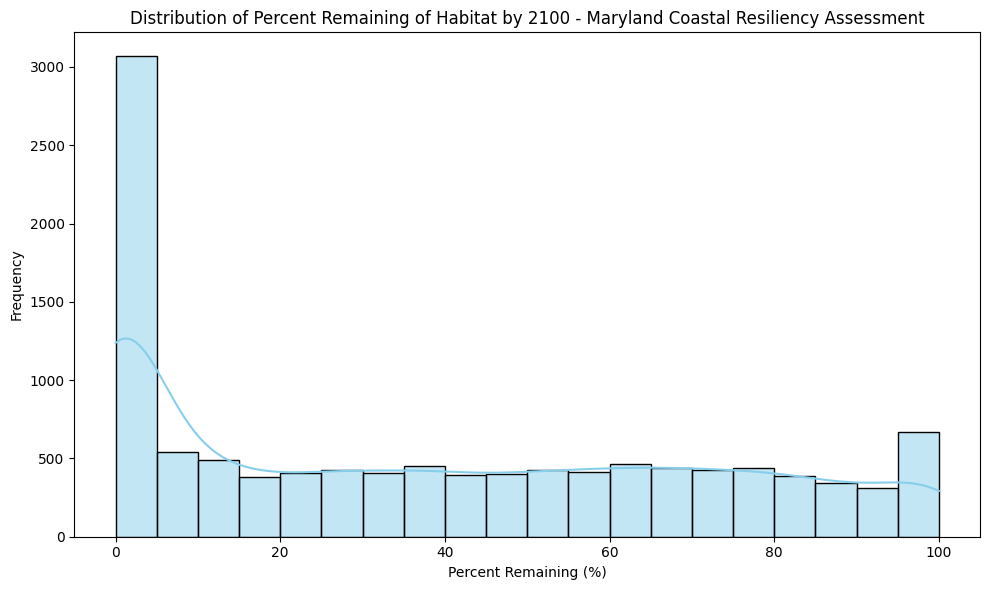

In [6]:
plt.figure(figsize=(10, 6))
sns.histplot(merged['PercentRemaining2100'].dropna(), bins=20, kde=True, color='skyblue')
plt.title('Distribution of Percent Remaining of Habitat by 2100 - Maryland Coastal Resiliency Assessment')
plt.xlabel('Percent Remaining (%)')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

Although we know that habitats are diminishing significantly, I wanted to visualize how habitat loss varies across habitat types. Clearly, some habitats are being disrupted more than others. For example, forests and marshes are set to lose over 60% of their area on average. On the other hand, underwater grass, oyster reefs, and dunes are to lose less than 60 percent of their area by 2100 on average. Allthough the difference is small, it is important to take it into account when applying strategies for prevention of loss.

Average Percent Habitat Loss by 2100 for Each Habitat Type (Higher values indicate more loss):


,0
Forest_Present,62.305451
Marsh_Present,61.584202
Underwater_Grass_Present,58.675640
Oyster_Reef_Present,56.706419
Dune_Present,53.041530


/tmp/ipykernel_6853/3002822165.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=habitat_loss_series.sort_values(ascending=False).index,


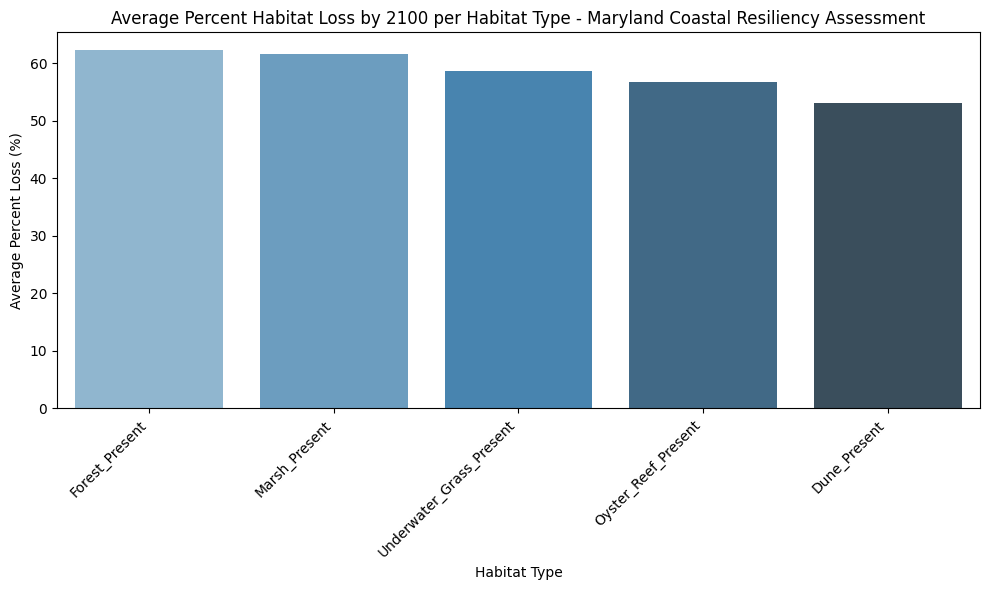

In [7]:
habitat_loss_by_type = {}

for h in habitats:

    habitat_present_data = merged[merged[h] == 1]
    # Calculating the mean of PercentRemaining2100 for these areas
    avg_percent_remaining = habitat_present_data['PercentRemaining2100'].mean()
    # Converting percent remaining to percent loss
    habitat_loss_by_type[h] = 100 - avg_percent_remaining


habitat_loss_series = pd.Series(habitat_loss_by_type)

print("Average Percent Habitat Loss by 2100 for Each Habitat Type (Higher values indicate more loss):")
display(habitat_loss_series.sort_values(ascending=False))


plt.figure(figsize=(10, 6))
sns.barplot(x=habitat_loss_series.sort_values(ascending=False).index,
            y=habitat_loss_series.sort_values(ascending=False).values,
            palette='Blues_d')
plt.title('Average Percent Habitat Loss by 2100 per Habitat Type - Maryland Coastal Resiliency Assessment')
plt.xlabel('Habitat Type')
plt.ylabel('Average Percent Loss (%)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

I thought that a bar chart comparing the habitat loss across counties could help to zoom in on what counties needed the most help. The range between averages is something to take into account with Caroline county having an average 74.7 percent loss of habitats and Worcester having only a 52.8 percent loss of habitats.

Average Percent Habitat Loss by 2100 per County


,PercentRemaining2100
County,
Caroline,74.682166
Prince George's,72.194298
Harford,71.904232
Queen Anne's,71.684206
Cecil,68.374478
Anne Arundel,66.908739
Talbot,63.893556
Baltimore City,63.772674
Dorchester,61.811604


/tmp/ipykernel_6853/3579129378.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=county_percent_loss.index, y=county_percent_loss.values, palette='Blues')


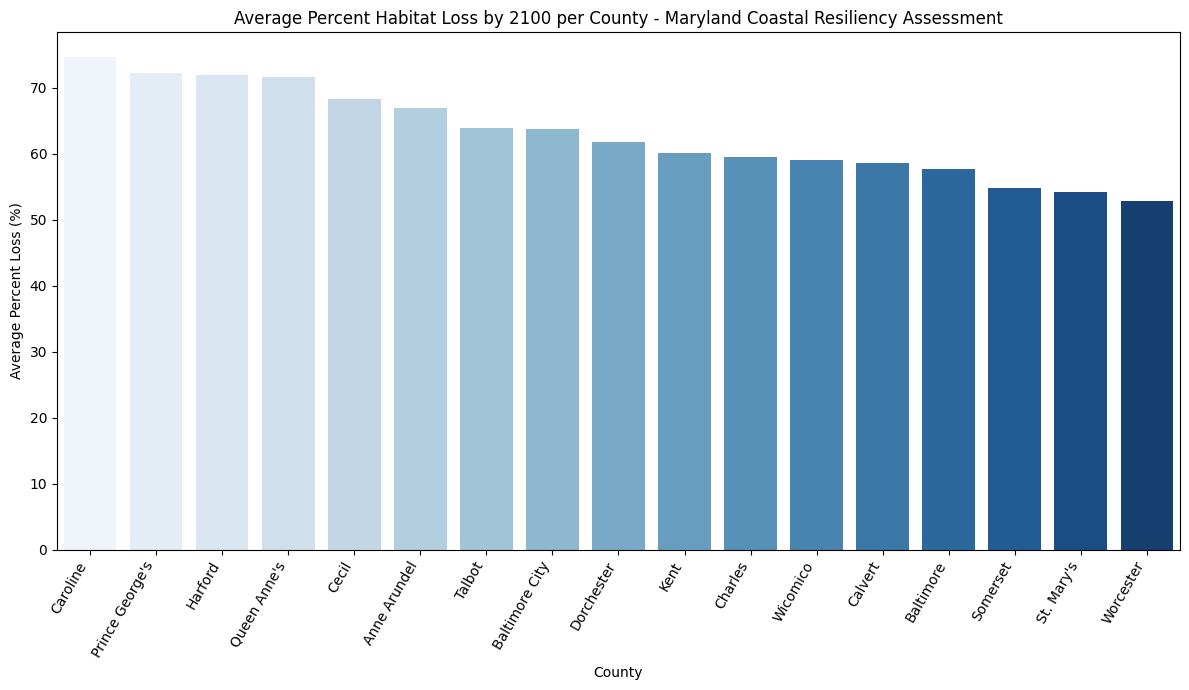

In [8]:
county_percent_remaining = merged.groupby('County')['PercentRemaining2100'].mean().sort_values(ascending=True)
county_percent_loss = 100 - county_percent_remaining

print("Average Percent Habitat Loss by 2100 per County")
display(county_percent_loss)

plt.figure(figsize=(12, 7))
sns.barplot(x=county_percent_loss.index, y=county_percent_loss.values, palette='Blues')
plt.title('Average Percent Habitat Loss by 2100 per County - Maryland Coastal Resiliency Assessment')
plt.xlabel('County')
plt.ylabel('Average Percent Loss (%)')
plt.xticks(rotation=60, ha='right')
plt.tight_layout()
plt.show()

Why should we even care about protecting our coastal habitats? Clearly shown in the boxplot below, we can see that when taking habitats into account, hazards are lower on average than without taking habitats into account. It is important to keep in mind that hazards in my data range from 0-4, or very low-very high. These hazards include geomorphology, elevation, sea level rising, waves, storm surges, and erosion.

/tmp/ipykernel_6853/4195444140.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Hazard Type', y='Hazard Level Numeric', data=plot_md, palette= 'Blues')


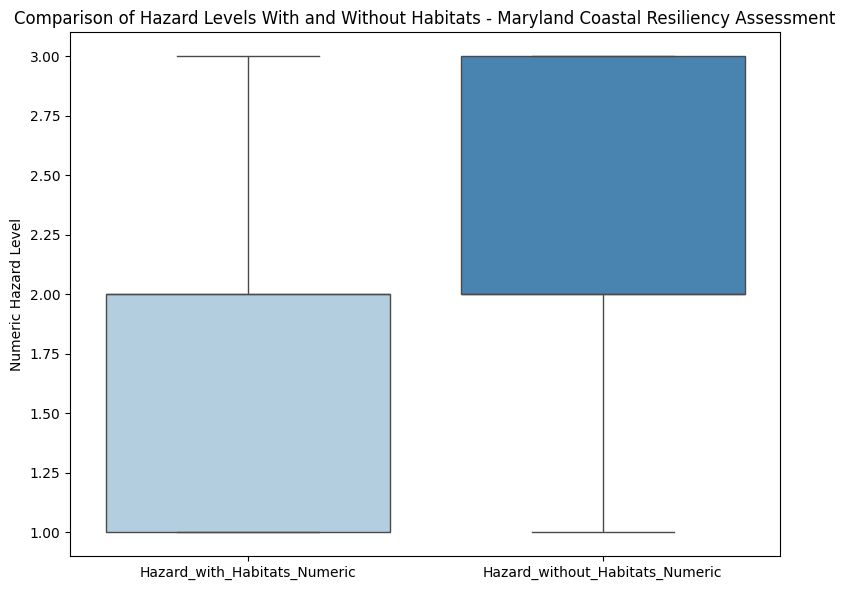

In [9]:
plot_md = merged[['Hazard_with_Habitats_Numeric', 'Hazard_without_Habitats_Numeric']].copy()
plot_md = plot_md.melt(var_name='Hazard Type', value_name='Hazard Level Numeric')

plt.figure(figsize=(8, 6))
sns.boxplot(x='Hazard Type', y='Hazard Level Numeric', data=plot_md, palette= 'Blues')
plt.title('Comparison of Hazard Levels With and Without Habitats - Maryland Coastal Resiliency Assessment')
plt.ylabel('Numeric Hazard Level')
plt.xlabel('')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

We can also see that the more habitat-diverse an area is, the more it reduces hazard risk. Having two or three different types of habitats protects against hazards more than only having one type. However, this is dangerous when we take into account the fact that these habitats are diminishing. The chance of having two or three strong habitats would be even weaker in the future.

Correlation between Number of Present Habitats and Hazard Reduction: 0.50


/tmp/ipykernel_6853/2117511906.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='num_habitats_present', y='Hazard_Reduction_by_Habitats_Numeric', data=merged, palette='Blues')


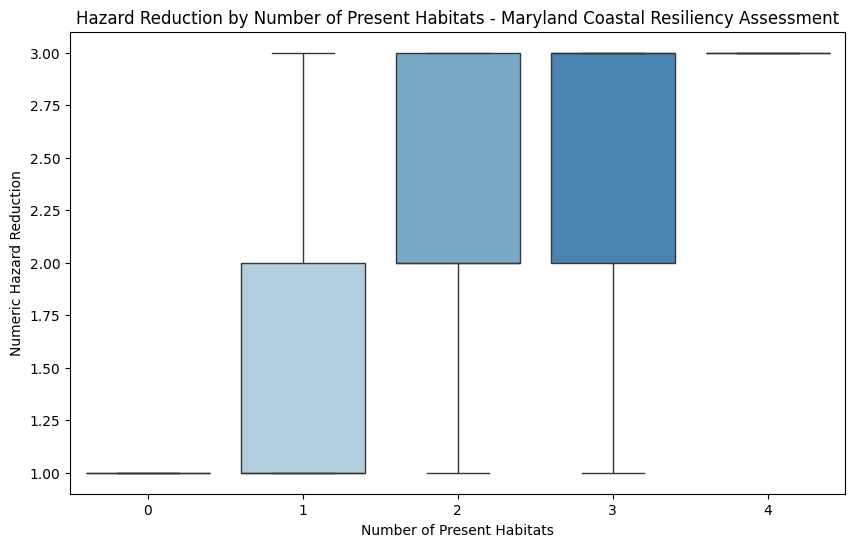

In [10]:
merged['num_habitats_present'] = merged[habitats].sum(axis=1)


correlation_num_habitats_reduction = merged['num_habitats_present'].corr(merged['Hazard_Reduction_by_Habitats_Numeric'])

print(f"Correlation between Number of Present Habitats and Hazard Reduction: {correlation_num_habitats_reduction:.2f}")


plt.figure(figsize=(10, 6))
sns.boxplot(x='num_habitats_present', y='Hazard_Reduction_by_Habitats_Numeric', data=merged, palette='Blues')
plt.title('Hazard Reduction by Number of Present Habitats - Maryland Coastal Resiliency Assessment')
plt.xlabel('Number of Present Habitats')
plt.ylabel('Numeric Hazard Reduction')
plt.show()

We can also visualize the average protection by habitat type for each county. From a previous example, we saw that Caroline county was at risk for a large amount of habitat loss. From this graph, we can see that Caroline county gets its protection against hazards from marshes and forests, which we know are depleting more than other coastal habitat types. Caroline county among others could be focal point for targeting habitat protection.

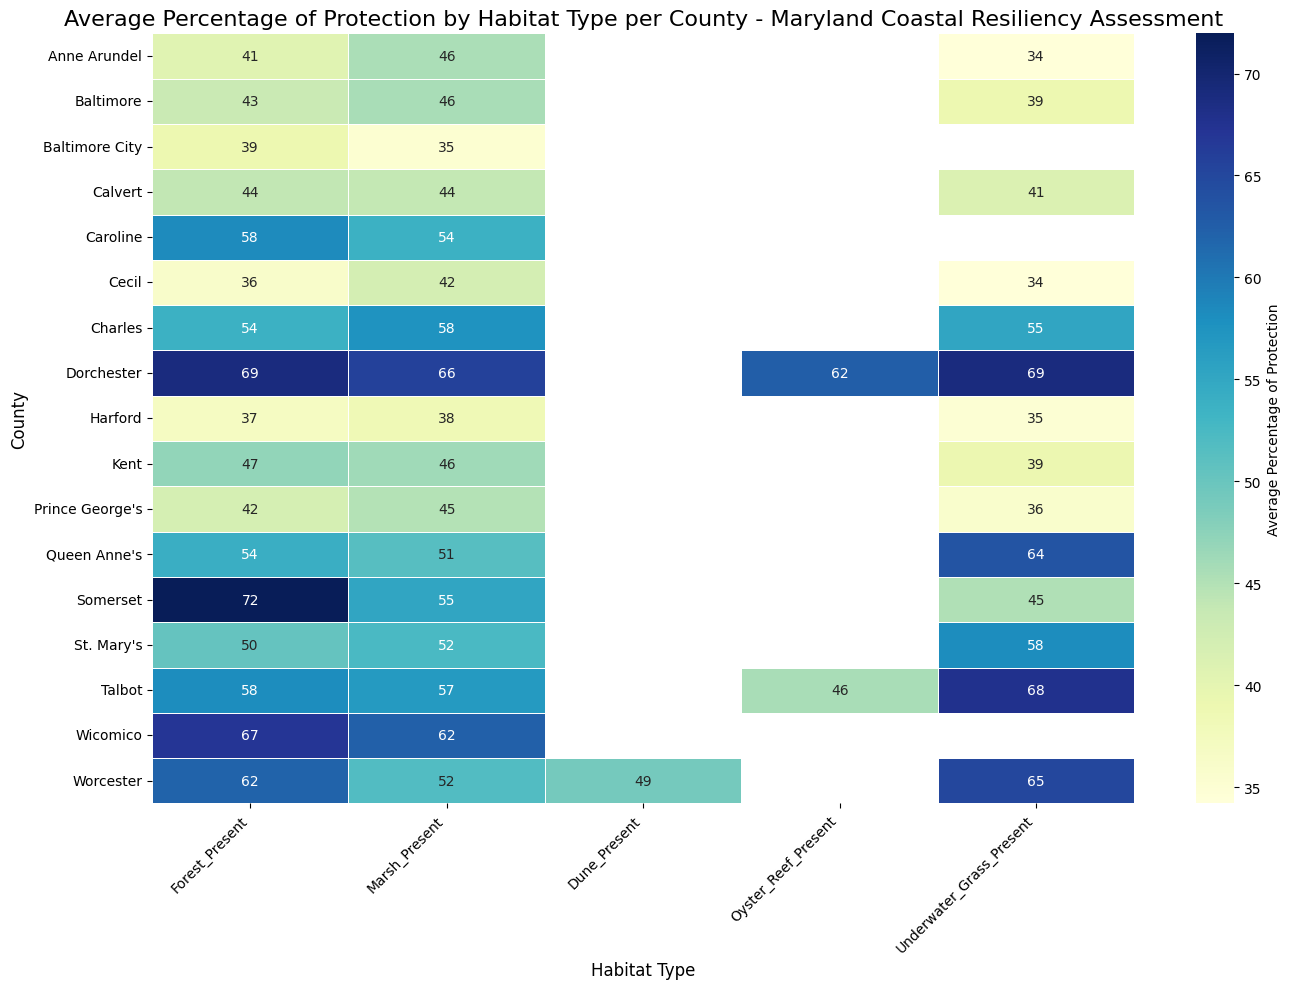

In [17]:
heatmap_data = {}

for h in habitats:
    habitat_county_reduction = merged[merged[h] == 1].groupby('County')['Hazard_Reduction_by_Habitats_Numeric'].mean()
    heatmap_data[h] = habitat_county_reduction

df_heatmap = pd.DataFrame(heatmap_data)


df_heatmap_percentage = (df_heatmap / 4) * 100

df_heatmap_percentage = df_heatmap_percentage.sort_index()

plt.figure(figsize=(14, 10))
sns.heatmap(df_heatmap_percentage, annot=True, cmap='YlGnBu', fmt=".0f", linewidths=.5, cbar_kws={'label': 'Average Percentage of Protection'})

plt.title('Average Percentage of Protection by Habitat Type per County - Maryland Coastal Resiliency Assessment', fontsize=16)
plt.xlabel('Habitat Type', fontsize=12)
plt.ylabel('County', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

While we know already that habitats are set to decrease in size, the first step to reduce this is to find out what could be causing this. From a sample of 1000 data points, I created a scatterplot showing the relationship between the percentage of a habitat's buffer (protective surroundings) remaining (not being occupied by humans) and the percentage of habitat remaining by 2100. I found that there was a positive relationship between the two variables, suggesting that the preservation of buffer areas is a significant factor in the long-term survival and resilience of habitats.

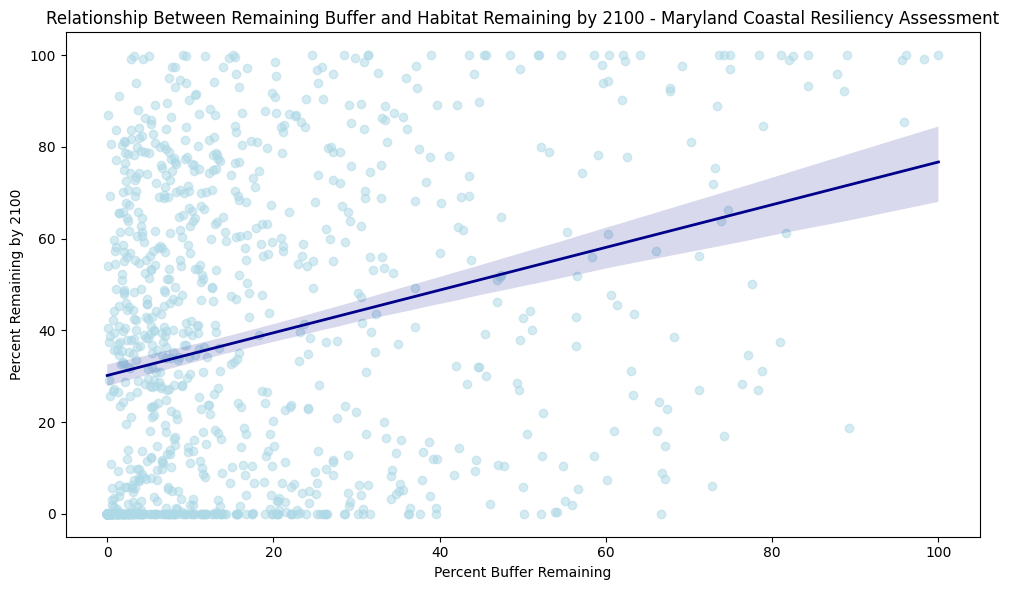

In [13]:
plt.figure(figsize=(10,6))

# Sample 1000 rows to reduce crowding
sampled_data = merged.sample(n=1000, random_state=42) if len(merged) > 1000 else merged

sns.regplot(
    data=sampled_data,
    x='PercentBufferRemain',
    y='PercentRemaining2100',
    scatter_kws={'alpha':0.5, 'color':'lightblue'},
    line_kws={'linewidth':2, 'color':'darkblue'}
)

plt.title('Relationship Between Remaining Buffer and Habitat Remaining by 2100 - Maryland Coastal Resiliency Assessment')
plt.xlabel('Percent Buffer Remaining')
plt.ylabel('Percent Remaining by 2100')

plt.tight_layout()
plt.show()